In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import json

In [ ]:
path = Path("../data/results")

df_all = pd.concat(
    [
        pd.json_normalize(json.load(open(file))[
                          "artifacts"]).assign(repo=file.stem)
        for file in path.glob("*-sbom.json")
    ],
    ignore_index=True
)

df_all = df_all.rename(columns={
    "name": "package"
})

df_all.head()

,id,package,version,type,foundBy,locations,licenses,language,cpes,purl,...,metadata.dependencies.@esbuild/linux-riscv64,metadata.dependencies.@esbuild/linux-s390x,metadata.dependencies.@esbuild/linux-x64,metadata.dependencies.@esbuild/netbsd-x64,metadata.dependencies.@esbuild/openbsd-x64,metadata.dependencies.@esbuild/sunos-x64,metadata.dependencies.@esbuild/win32-arm64,metadata.dependencies.@esbuild/win32-ia32,metadata.dependencies.@esbuild/win32-x64,metadata.dependencies.flowise-embed-react
0,0283ff70c757864e,@aashutoshrathi/word-wrap,1.2.6,npm,javascript-lock-cataloger,"[{'path': '/pnpm-lock.yaml', 'accessPath': '/p...",[],javascript,[{'cpe': 'cpe:2.3:a:\@aashutoshrathi\/word-wra...,pkg:npm/%40aashutoshrathi/word-wrap@1.2.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,149ca2f5cd7a0935,@adobe/css-tools,4.3.3,npm,javascript-lock-cataloger,"[{'path': '/pnpm-lock.yaml', 'accessPath': '/p...",[],javascript,[{'cpe': 'cpe:2.3:a:adobe:css-tools:4.3.3:*:*:...,pkg:npm/%40adobe/css-tools@4.3.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b332513e51df82a8,@adobe/css-tools,4.4.4,npm,javascript-lock-cataloger,"[{'path': '/pnpm-lock.yaml', 'accessPath': '/p...",[],javascript,[{'cpe': 'cpe:2.3:a:adobe:css-tools:4.4.4:*:*:...,pkg:npm/%40adobe/css-tools@4.4.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bdcc0d397ed9a86c,@ai-sdk/openai,3.0.2,npm,javascript-lock-cataloger,"[{'path': '/pnpm-lock.yaml', 'accessPath': '/p...",[],javascript,[{'cpe': 'cpe:2.3:a:\@ai-sdk\/openai:\@ai-sdk\...,pkg:npm/%40ai-sdk/openai@3.0.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8dd563c7984906f1,@ai-sdk/provider,0.0.10,npm,javascript-lock-cataloger,"[{'path': '/pnpm-lock.yaml', 'accessPath': '/p...",[],javascript,[{'cpe': 'cpe:2.3:a:\@ai-sdk\/provider:\@ai-sd...,pkg:npm/%40ai-sdk/provider@0.0.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_all['repo'].value_counts()

repo
Flowise-sbom              4540
FlowiseEmbedReact-sbom     604
FlowiseChatEmbed-sbom      380
Name: count, dtype: int64

In [5]:
df_all['licenses'].explode().value_counts().head(10)

licenses
{'value': 'MIT', 'spdxExpression': 'MIT', 'type': 'declared', 'urls': [], 'locations': [{'path': '/package-lock.json', 'accessPath': '/package-lock.json', 'annotations': {'evidence': 'primary'}}]}                                                                              158
{'value': 'MIT', 'spdxExpression': 'MIT', 'type': 'declared', 'urls': [], 'locations': [{'path': '/packages/agentflow/examples/package-lock.json', 'accessPath': '/packages/agentflow/examples/package-lock.json', 'annotations': {'evidence': 'primary'}}]}                      120
{'value': 'MIT', 'spdxExpression': 'MIT', 'type': 'declared', 'urls': [], 'locations': [{'path': '/packages/observe/examples/package-lock.json', 'accessPath': '/packages/observe/examples/package-lock.json', 'annotations': {'evidence': 'primary'}}]}                           79
{'value': 'ISC', 'spdxExpression': 'ISC', 'type': 'declared', 'urls': [], 'locations': [{'path': '/packages/agentflow/examples/package-lock.json', 'accessPat

In [7]:
summary = {
    "total_repos": df_all["repo"].nunique(),
    "total_components": len(df_all),
}
summary

{'total_repos': 3, 'total_components': 5524}

In [3]:
schemas = set()

for file in path.glob("*-sbom.json"):
    data = json.load(open(file))
    schemas.add(tuple(sorted(data.keys())))

schemas

{('artifactRelationships',
  'artifacts',
  'descriptor',
  'distro',
  'files',
  'schema',
  'source'),
 ('artifactRelationships',
  'artifacts',
  'descriptor',
  'distro',
  'schema',
  'source')}

In [4]:
artifact_keys = set()

for file in path.glob("*-sbom.json"):
    data = json.load(open(file))
    for art in data["artifacts"]:
        artifact_keys.update(art.keys())

artifact_keys

{'cpes',
 'foundBy',
 'id',
 'language',
 'licenses',
 'locations',
 'metadata',
 'metadataType',
 'name',
 'purl',
 'type',
 'version'}

In [6]:
df_all["package"].value_counts().head(15)

package
debug                           21
ms                              16
commander                       13
lru-cache                       13
chalk                           11
qs                              11
type-fest                       11
ansi-styles                     10
function-bind                   10
jsesc                           10
safe-buffer                     10
@babel/helper-module-imports     9
@jridgewell/trace-mapping        9
cookie                           9
encodeurl                        9
Name: count, dtype: int64

In [7]:
df_all["type"].value_counts()

type
npm              5500
github-action      24
Name: count, dtype: int64

In [ ]:
df_all.groupby("package")["repo"].nunique(
).sort_values(ascending=False).head(10)

package
which                     3
@ampproject/remapping     3
yallist                   3
zod                       3
web-streams-polyfill      3
vary                      3
util-deprecate            3
utils-merge               3
unpipe                    3
update-browserslist-db    3
Name: repo, dtype: int64

In [ ]:
df_all.groupby("package")["version"].nunique(
).sort_values(ascending=False).head(10)

package
commander                            11
debug                                 9
type-fest                             8
@aws-sdk/credential-provider-env      7
@aws-sdk/core                         7
@aws-sdk/util-user-agent-browser      7
@aws-sdk/util-endpoints               7
lru-cache                             7
@aws-sdk/credential-provider-http     7
@aws-sdk/credential-provider-sso      7
Name: version, dtype: int64

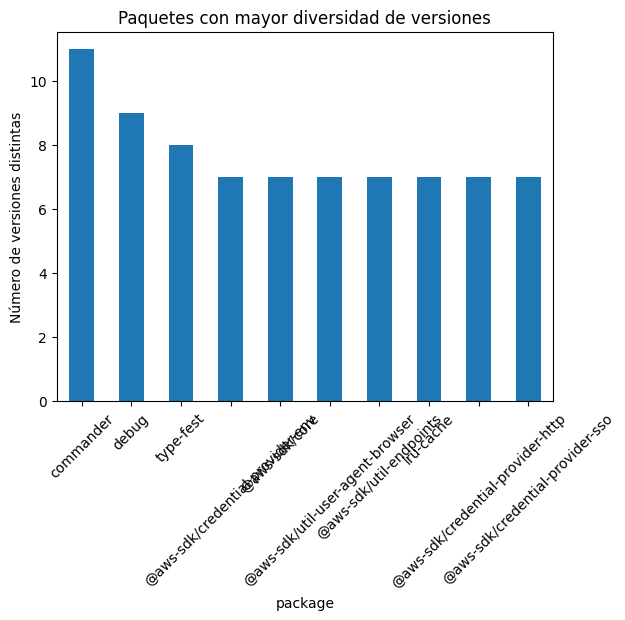

In [13]:
version_spread = (
    df_all.groupby("package")["version"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

version_spread.plot(kind="bar")
plt.title("Paquetes con mayor diversidad de versiones")
plt.ylabel("Número de versiones distintas")
plt.xticks(rotation=45)
plt.show()

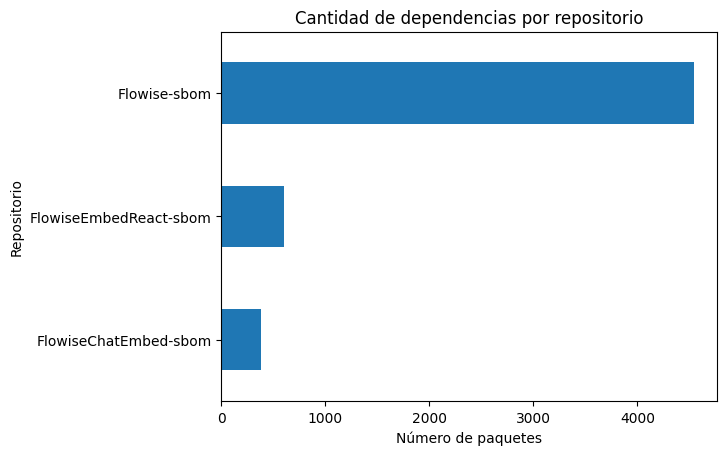

In [14]:
deps_per_repo = df_all.groupby("repo")["package"].count()

deps_per_repo.sort_values().plot(kind="barh")
plt.title("Cantidad de dependencias por repositorio")
plt.xlabel("Número de paquetes")
plt.ylabel("Repositorio")
plt.show()

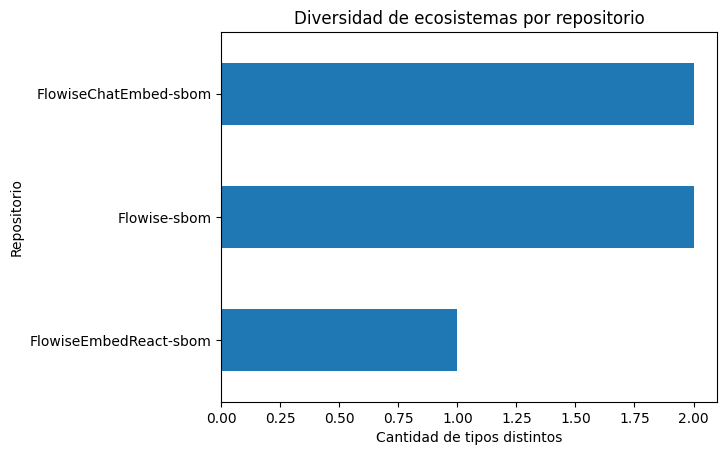

In [15]:
tech_div = df_all.groupby("repo")["type"].nunique()

tech_div.sort_values().plot(kind="barh")
plt.title("Diversidad de ecosistemas por repositorio")
plt.xlabel("Cantidad de tipos distintos")
plt.ylabel("Repositorio")
plt.show()

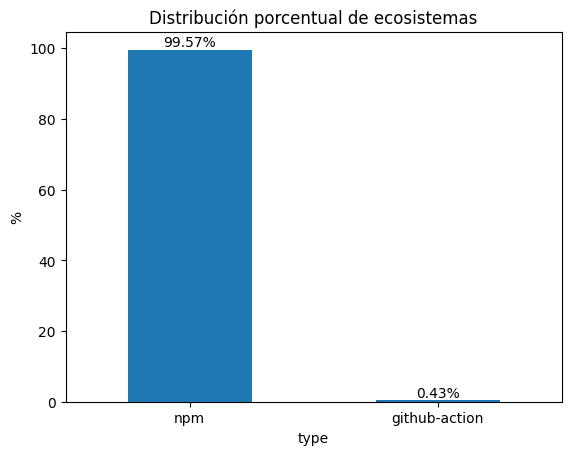

In [ ]:
ax = (df_all["type"].value_counts(normalize=True) * 100).plot(
    kind="bar"
)

plt.title("Distribución porcentual de ecosistemas")
plt.ylabel("%")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()